In [ ]:
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, confusion_matrix
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Load dataset
dataset = pd.read_csv('../data/processed/processed_dataset.csv')

# drop irrelevant columns
df = dataset.drop(columns=['imei_list']) 
df.drop(columns=[ "voc_hour_mode",'voc_day_mode','sms_hour_mode','sms_day_mode'], inplace=True)

# Fill NaN values with the median of each column
df = df.apply(lambda x: x.fillna(x.median()) if x.dtype in ['float64', 'int64'] else x.fillna(x.mode()[0]))

# Separate the labels and features
labels = df[['phone_no_m', 'label']]  # Extract label columns
features = df.drop(columns=['label'])  # Drop the label column to keep only the features

# Scale the features (exclude 'phone_no_m' from scaling)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features.drop(columns=['phone_no_m']))  # Scale the features

# Store the scaled features and labels
feature_dict = pd.DataFrame(scaled_features, index=features["phone_no_m"]).to_dict(orient="index")  # Store scaled features as a dictionary
label_dict = labels.set_index("phone_no_m").to_dict(orient="index")  # Store labels as a dictionary

# Compute cosine similarity on the PCA-transformed features
similarity_matrix = cosine_similarity(scaled_features)  # Compute cosine similarity matrix
similarity_df = pd.DataFrame(similarity_matrix, index=df["phone_no_m"], columns=df["phone_no_m"])  # Create a similarity DataFrame


# Create Graph
G = nx.Graph()

for idx, row in df.iterrows():
    G.add_node(row['phone_no_m'], label=row['label'])

# Configuration
threshold = 0.90  # Original threshold for strong connections
target_positive = 14  # Neighbors with highest positive similarity
target_negative = 6   # Neighbors with most negative similarity

# Create Graph
G = nx.Graph()

for idx, row in df.iterrows():
    G.add_node(row['phone_no_m'], label=row['label'])


k_nearest_neighbours = 15  ## during testing, this value has been adjusted from 10,15,20,50

for i, phone1 in enumerate(df["phone_no_m"]):
    
    similarities = [
        (j, similarity_matrix[i, j])
        for j in range(len(df["phone_no_m"])) if i != j
    ]

    positive = sorted([p for p in similarities], key=lambda x: x[1], reverse=True)

    # Select neighbors based strictly on k-nearest neighbours
    selected = []
    selected += positive[:k_nearest_neighbours]

    # Step 6: Add edges to graph (skip padding!)
    for neighbor_idx, sim in selected:
        neighbor = df["phone_no_m"].iloc[neighbor_idx]
        G.add_edge(phone1, neighbor, weight=sim)



Probabilistic Relational Neighbour Classifier

In [3]:
g1 = nx.convert_node_labels_to_integers(G, label_attribute="original_phone_no")

In [4]:
node_list = list(g1.nodes)

# train test split nodes
train, test = train_test_split(node_list)

In [5]:
# for train nodes, calculate posterior class probability and add f_prob, nf_prob respectively as node attributes

for node in train:
    neighbors = list(g1.neighbors(node))
    neighbor_len = len(neighbors)
    count_fraud = 0
    count_nfraud = 0
    for other in neighbors:
        if other in train:
            label = g1.nodes[other]['label']
            if label == 1:
                count_fraud += 1
            else:
                count_nfraud +=1
        else:
            neighbor_len -= 1
    prob_fraud = count_fraud/neighbor_len
    prob_non_fraud = count_nfraud/neighbor_len

    attrs = {node: {"f_prob": prob_fraud, "nf_prob": prob_non_fraud}} 

    nx.set_node_attributes(g1, attrs)
    # print(g1.nodes[node]) 

In [6]:
# get probability of fraud/non fraud for test nodes
# doesnt make use of test nodes with probabilities that have been calculated

phones_test = []
original_test_label = []
predicted_test_label = []

for node in test:
    neighbors = list(g1.neighbors(node))
    neighbor_len = len(neighbors)
    
    sum_prob_fraud = 0
    sum_prob_non_fraud = 0

    for other in neighbors:
        if other in train:
            sum_prob_fraud += g1.nodes[other]['f_prob']
            sum_prob_non_fraud += g1.nodes[other]['nf_prob']
        else:
            neighbor_len -= 1

    prob_fraud = sum_prob_fraud/neighbor_len
    prob_nfraud = sum_prob_non_fraud/neighbor_len

    if prob_fraud >= prob_nfraud:
        predicted_test_label.append(1)
    else: 
        predicted_test_label.append(0)

    phones_test.append(g1.nodes[node]["original_phone_no"])
    original_test_label.append(g1.nodes[node]["label"])
    # print(f"prob fraud: {prob_fraud}, prob non fraud: {prob_nfraud}")

In [7]:
# Evaluation function

def evaluate_labels (predicted, actual):
    print(f"ROC-AUC score: {roc_auc_score(actual, predicted)}")
    cm = confusion_matrix(actual, predicted)
    cm = pd.DataFrame(cm)
    #cm.index = ["actual 0", "actual 1"]
    #cm.columns = ["predicted 0", "predicted 1"]
    print(f"\nConfusion matrix:")
    print(cm)
    print(f"\nClassification report:")
    print(classification_report(actual, predicted))

In [11]:
evaluate_labels(predicted_test_label, original_test_label)

ROC-AUC score: 0.8604895472213467

Confusion matrix:
      0    1
0  1008   18
1   131  370

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      1026
           1       0.95      0.74      0.83       501

    accuracy                           0.90      1527
   macro avg       0.92      0.86      0.88      1527
weighted avg       0.91      0.90      0.90      1527



Relational neighbor classifier

In [ ]:
# get probability of fraud/non fraud for test nodes
# doesnt make use of test nodes with probabilities that have been calculated

phones_test = []
original_test_label = []
predicted_test_label = []

for node in test:
    neighbors = list(g1.neighbors(node))
    neighbor_len = len(neighbors)
    
    count_fraud = 0
    count_nfraud = 0
    for other in neighbors:
        if other in train:
            label = g1.nodes[other]['label']
            if label == 1:
                count_fraud += 1
            else:
                count_nfraud +=1
        else:
            neighbor_len -= 1
            
    prob_fraud = count_fraud/neighbor_len
    prob_nfraud = count_nfraud/neighbor_len

    if prob_fraud >= prob_nfraud:
        predicted_test_label.append(1)
    else: 
        predicted_test_label.append(0)

    phones_test.append(g1.nodes[node]["original_phone_no"])
    original_test_label.append(g1.nodes[node]["label"])

In [13]:
evaluate_labels(predicted_test_label, original_test_label)

ROC-AUC score: 0.8660135868613651

Confusion matrix:
      0    1
0  1005   21
1   124  377

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      1026
           1       0.95      0.75      0.84       501

    accuracy                           0.91      1527
   macro avg       0.92      0.87      0.89      1527
weighted avg       0.91      0.91      0.90      1527



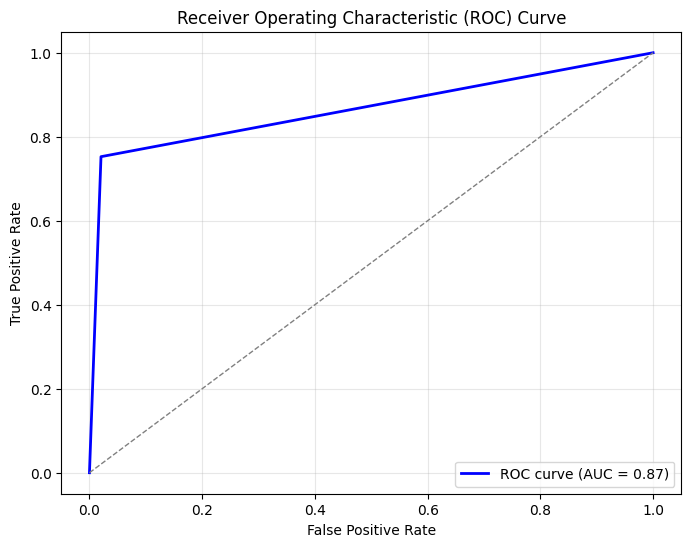

In [14]:
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt

# Compute the ROC curve and AUC score
fpr, tpr, _ = roc_curve(original_test_label, predicted_test_label)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()
